In [ ]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import resample
from agents.ffnn_agent2 import FFNNAgent
from torch.utils.data import TensorDataset, DataLoader
import torch
import matplotlib.pyplot as plt
import random

In [63]:
train_size=3000
bias_pct=0.9
seed=42
pca_components=2

In [ ]:

# Ensure all randomness is seeded
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

#Fetch dataset
adult = fetch_ucirepo(id=2)
X_df = adult.data.features  
y_df = adult.data.targets   

X = X_df.values
y = np.ravel(y_df.values)

# Map labels to 0/1
y = np.where(np.isin(y, ['>50K', '>50K.']), 1, 0)

# Identify categorical and numerical columns
cat_cols = [i for i, dt in enumerate(X_df.dtypes) if dt.name in ['category', 'object', 'bool']]
num_cols = [i for i, dt in enumerate(X_df.dtypes) if np.issubdtype(dt, np.number)]

# One-hot encode categoricals, standardize numericals
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(X[:, cat_cols]) if cat_cols else np.empty((X.shape[0], 0))

scaler = StandardScaler()
X_num = scaler.fit_transform(X[:, num_cols]) if num_cols else np.empty((X.shape[0], 0))

# stack back together
X_all = np.hstack([X_num, X_cat])
y_all = y

# For balancing, target is last column
df_all = np.hstack([X_all, y_all.reshape(-1, 1)])

target_col = -1
majority_mask = df_all[:, target_col] == 0
minority_mask = df_all[:, target_col] == 1

df_majority = df_all[majority_mask]
df_minority = df_all[minority_mask]

# Upsample minority class
n_majority = df_majority.shape[0]
n_minority = df_minority.shape[0]

# Use seeded random generator for reproducibility
rng = np.random.default_rng(seed)
indices = rng.choice(n_minority, size=n_majority, replace=True)
df_minority_upsampled = df_minority[indices]

# Concatenate and shuffle
df_balanced = np.vstack([df_majority, df_minority_upsampled])
rng.shuffle(df_balanced)

X_bal = df_balanced[:, :-1]
y_bal = df_balanced[:, -1]

# Bias the dataset: remove a percentage of Class 1 examples from the balanced set
df_balanced_pd = pd.DataFrame(X_bal, columns=[f'feat_{i}' for i in range(X_bal.shape[1])])
df_balanced_pd['target'] = y_bal

# Separate class 0 and class 1
df_class_0 = df_balanced_pd[df_balanced_pd['target'] == 0]
df_class_1 = df_balanced_pd[df_balanced_pd['target'] == 1]

# Remove a fraction of class 1
df_class_1_biased = df_class_1.sample(frac=1 - bias_pct, random_state=seed)
df_biased = pd.concat([df_class_0, df_class_1_biased], axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)

X_biased = df_biased.drop('target', axis=1).values
y_biased = df_biased['target'].values

#PCA analysis 
pca = PCA(n_components=pca_components, random_state=seed)
X_biased_pca = pca.fit_transform(X_biased)

#Train-test split after biasing and PCA
X_train, X_test_theta, y_train, y_test_theta = train_test_split(
    X_biased_pca, y_biased, test_size=0.2, random_state=seed, stratify=y_biased
)

# If train_size is specified, subsample the train set to the requested size
# Bias in class distribution is maintained.
if train_size is not None:
    if train_size < len(X_train):
        # Stratified subsample to preserve the biased class distribution
        X_train_sub, _, y_train_sub, _ = train_test_split(
            X_train, y_train, train_size=train_size, random_state=seed, stratify=y_train
        )
        X_train_theta = X_train_sub
        y_train_theta = y_train_sub

X_train_theta = np.array(X_train_theta)
X_test_theta = np.array(X_test_theta)
y_train_theta = np.array(y_train_theta)
y_test_theta = np.array(y_test_theta)

In [65]:
# Open a CSV of format: pca_0,pca_1,...,pca_{n-1},target and concatenate it to the trainset
# Path to the synthetic trajectory CSV
synth_csv_path = "synthetic_trajectory.csv"

# Read the synthetic data
synth_df = pd.read_csv(synth_csv_path)

# Dynamically determine PCA columns based on pca_components
pca_columns = [f"pca_{i}" for i in range(pca_components)]
all_columns = pca_columns + ["target"]

# Ensure the columns exist in the CSV
missing_cols = [col for col in all_columns if col not in synth_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in synthetic CSV: {missing_cols}")

# Extract features and target dynamically
synth_X = synth_df[pca_columns].values
synth_y = synth_df["target"].values

# Concatenate synthetic data to the training set
X_train_phi = np.concatenate([X_train_theta, synth_X], axis=0)
y_train_phi = np.concatenate([y_train_theta, synth_y], axis=0)


FFNN Using device: cpu
FFNN Using device: cpu
Shape of X_train_phi: (4000, 2)
Shape of y_train_phi: (4000,)


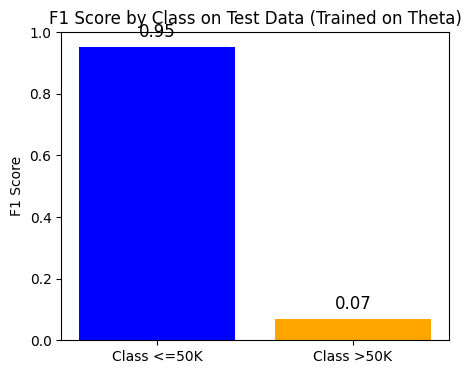

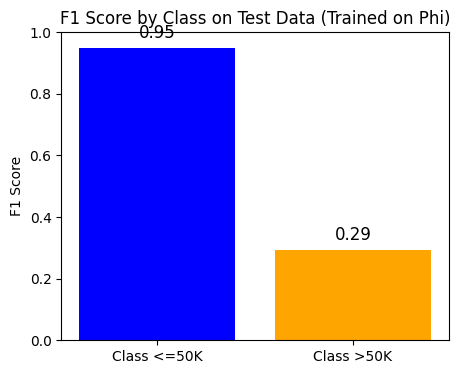

In [ ]:
# Train FFNNAgent on theta (real) and phi (real+synthetic) data, compare both on theta test set


ffnn_config = {
    'input_size': X_train.shape[1],
    'hidden_sizes': [32, 16],
    'output_size': 1,
    'learning_rate': 0.001,
    'batch_size': 64,
    'epochs': 10,
    'type': 'classification',
    'classes': [0, 1],
    'seed': seed
}

# Create agents
agent_theta = FFNNAgent(**ffnn_config)
agent_phi = FFNNAgent(**ffnn_config)

# Prepare DataLoaders with seeded shuffling
print("Shape of X_train_phi:", X_train_phi.shape)
print("Shape of y_train_phi:", y_train_phi.shape)
phi_dataset = TensorDataset(torch.tensor(X_train_phi, dtype=torch.float32), torch.tensor(y_train_phi, dtype=torch.long))
phi_train_loader = DataLoader(phi_dataset, batch_size=ffnn_config['batch_size'], shuffle=True, generator=torch.Generator().manual_seed(seed))

theta_dataset = TensorDataset(torch.tensor(X_train_theta, dtype=torch.float32), torch.tensor(y_train_theta, dtype=torch.long))
theta_train_loader = DataLoader(theta_dataset, batch_size=ffnn_config['batch_size'], shuffle=True, generator=torch.Generator().manual_seed(seed))

# Train both agents
agent_theta.train(theta_train_loader)
agent_phi.train(phi_train_loader)

# Predict on theta test set with both agents
y_pred_theta = agent_theta.predict(X_test_theta)
y_pred_phi = agent_phi.predict(X_test_theta)

# Ensure numpy arrays
y_pred_theta = np.array(y_pred_theta)
y_pred_phi = np.array(y_pred_phi)


#f1_theta_ = f1_score(y_test_theta, np.round(y_pred_theta), pos_label=0, average='weight')

# # Compute F1 scores per class for both agents
f1_theta_both = f1_score(y_test_theta, np.round(y_pred_theta), average='weighted')

f1_phi_both = f1_score(y_test_theta, np.round(y_pred_phi), average='weighted')


# Compute F1 scores per class for both agents
f1_theta_0 = f1_score(y_test_theta, np.round(y_pred_theta), pos_label=0)
f1_theta_1 = f1_score(y_test_theta, np.round(y_pred_theta), pos_label=1)

f1_phi_0 = f1_score(y_test_theta, np.round(y_pred_phi), pos_label=0)
f1_phi_1 = f1_score(y_test_theta, np.round(y_pred_phi), pos_label=1)

# Plot for agent trained on theta
plt.figure(figsize=(5, 4))
plt.bar(['Class <=50K', 'Class >50K'], [f1_theta_0, f1_theta_1], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.title('F1 Score by Class on Test Data (Trained on Theta)')
for i, v in enumerate([f1_theta_0, f1_theta_1]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=12)
plt.show()

# Plot for agent trained on phi
plt.figure(figsize=(5, 4))
plt.bar(['Class <=50K', 'Class >50K'], [f1_phi_0, f1_phi_1], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.title('F1 Score by Class on Test Data (Trained on Phi)')
for i, v in enumerate([f1_phi_0, f1_phi_1]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=12)
plt.show()


# Plot for weighted f1 scores between models
plt.figure(figsize=(5, 4))
plt.bar(['Model Theta (Real)', 'Model Phi (Hybrid)'], [f1_theta_both, f1_phi_both], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.title('F1 Score by model on Test Data')
for i, v in enumerate([f1_phi_0, f1_phi_1]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=12)
plt.show()

In [ ]:
#overall f1 score comparing phi and theta